<a href="https://colab.research.google.com/github/DreWona/Module3_CameraSimilarity/blob/main/Module_3_Camera_Sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline
import pandas as pd

import json

In [2]:
camera_feature_map = {}

In [3]:
with open('cam_deet.json', 'r') as in_file:
  for this_camera in json.load(in_file):
    #numerical feature points
    mp = this_camera.get('Effective megapixels')
    crop = this_camera.get('Crop factor')
    screen = this_camera.get('Screen size')

    if any(v is None or v == '' for v in [mp, crop, screen]):
      continue
      #Remap feature yes or no feature points to 1 or 0
      #dataset id  as brand+camera model because the aarchive didnt come with a ID's
    camera_id = str(this_camera['Brand']).strip() + ' ' + str(this_camera['Model']).strip()
    camera_feature_map[camera_id] = {
        'megapixels': float(str(mp)),
        'crop_factor': float(str(crop)),
        'screen_size': float(str(screen).replace(',', '.')),
        'raw_support': 1 if str(this_camera.get('RAW support', '')).lower() == 'yes' else 0,
        'wireless': 1 if str(this_camera.get('Wireless', '')).lower() == 'yes' else 0,
        'aperture_priority': 1 if str(this_camera.get('Aperture priority', '')).lower() == 'yes' else 0
    }
  print(f"Cameras loaded: {len(camera_feature_map)}")


Cameras loaded: 1841


In [4]:
df = pd.DataFrame.from_dict(camera_feature_map, orient='index').fillna(0)
df.head(1167)

,megapixels,crop_factor,screen_size,raw_support,wireless,aperture_priority
Canon EOS 850D,24.1,1.61,3.0,1,1,1
Canon EOS-1D X Mark III,20.1,1.00,3.2,1,1,1
Canon EOS M200,24.1,1.61,3.0,1,1,1
Canon EOS 90D,32.5,1.61,3.0,1,1,1
Canon EOS M6 Mark II,32.5,1.61,3.0,1,1,1
...,...,...,...,...,...,...
Pentax Optio S7,7.1,6.02,2.5,0,0,0
Pentax Optio A10,8.0,4.87,2.5,0,0,0
Pentax *ist DL2,6.1,1.53,2.5,0,0,1
Pentax K110D,6.1,1.53,2.5,0,0,1


In [5]:
df.index[[270, 500, 800, 750, 400]]

Index(['Fujifilm X-E2', 'Nikon Coolpix S2700', 'Olympus FE-115',
       'Olympus PEN E-P1', 'Leica D-LUX 4'],
      dtype='object')

In [6]:
df[df.index.str.contains('Nikon')][:5]

,megapixels,crop_factor,screen_size,raw_support,wireless,aperture_priority
Nikon Z50,20.9,1.53,3.2,1,1,1
Nikon Coolpix W150,13.2,7.21,2.7,0,1,0
Nikon Coolpix B600,16.0,5.62,3.0,0,1,0
Nikon Coolpix A1000,16.0,5.62,3.0,1,1,1
Nikon Z7,45.7,1.00,3.2,1,1,1


In [ ]:
df[df.index.str.contains('Sony')][:5]

,megapixels,crop_factor,screen_size,raw_support,wireless,aperture_priority
Sony Alpha a9 II,24.2,1.01,3.0,1,1,1
Sony a6600,24.2,1.53,3.0,1,1,1
Sony a6100,24.2,1.53,3.0,1,1,1
Sony a7R IV,61.0,1.01,3.0,1,1,1
Sony Alpha a6400,24.2,1.53,3.0,1,1,1


In [7]:
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import MinMaxScaler

In [8]:
num_cols = ['megapixels', 'crop_factor', 'screen_size']
df_norm = df.copy()
df_norm[num_cols] = MinMaxScaler().fit_transform(df[num_cols])

In [9]:
#My 3 cameras sets
query_cameras = ['Canon EOS 850D', 'Sony a7R IV', 'Nikon Z7']

In [55]:
# 10 Reps of similar cams
for target_camera_id in query_cameras:

    target_camera_ratings = df_norm.loc[target_camera_id]
    distances = cosine_distances(df_norm, [target_camera_ratings])[:, 0]
    query_distances = list(zip(df_norm.index, distances))

    print(f"\n{'='*55}")
    print(f"  Top 10 most similar to: {target_camera_id}")
    print(f"{'='*55}")

    count = 0
    for similar_camera_id, similar_score in sorted(query_distances, key=lambda x: x[1]):
        if similar_camera_id == target_camera_id:
            continue
        print(similar_camera_id, round(1 - similar_score, 4))
        count += 1
        if count == 10:
            break


  Top 10 most similar to: Canon EOS 850D
Canon EOS M200 1.0
Canon EOS 250D 1.0
Canon EOS M50 1.0
Canon EOS Rebel T7 1.0
Canon PowerShot G1 X Mark III 1.0
Canon EOS M100 1.0
Canon EOS Rebel SL2 1.0
Canon EOS Rebel T7i 1.0
Canon EOS 77D 1.0
Canon EOS M6 1.0

  Top 10 most similar to: Sony a7R IV
Leica Q2 0.9949
Panasonic Lumix DC-S1R 0.9941
Nikon Z7 0.9928
Nikon D850 0.9928
Sony Alpha a7R III 0.9903
Sony Alpha A99 II 0.9903
Sony Cyber-shot DSC-RX1R II 0.9903
Sony Alpha 7R II 0.9903
Pentax K-1 Mark II 0.9813
Pentax K-1 0.9813

  Top 10 most similar to: Nikon Z7
Nikon D850 1.0
Panasonic Lumix DC-S1R 0.9999
Leica Q2 0.9994
Sony Alpha a7R III 0.9993
Sony Alpha A99 II 0.9993
Sony Cyber-shot DSC-RX1R II 0.9993
Sony Alpha 7R II 0.9993
Pentax K-1 Mark II 0.9972
Pentax K-1 0.9972
Canon EOS 90D 0.993


In [54]:

all_results = []

for target_camera_id in query_cameras:
    target_camera_ratings = df_norm.loc[target_camera_id]
    distances = cosine_distances(df_norm, [target_camera_ratings])[:, 0]
    query_distances = list(zip(df_norm.index, distances))

    count = 0
    for similar_camera_id, similar_score in sorted(query_distances, key=lambda x: x[1]):
        if similar_camera_id == target_camera_id:
            continue
        all_results.append({
            'Cameras': target_camera_id,
            'similar_camera': similar_camera_id,
            'cosine_similarity': round(1 - similar_score, 4)
        })
        count += 1
        if count == 10:
            break


results_df = pd.DataFrame(all_results)
results_df.to_csv('Similar_Cameras.csv', index=False)

# EXTENSION: FINAL


## Module 2: Networks

In [42]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# Extract brand from camera_id index (e.g. 'Canon EOS 850D' → 'Canon')
brand_map = dict(zip(df_norm.index, df_norm.index.str.split(' ', n=1).str[0]))

In [44]:
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms.community import louvain_communities

In [52]:
# Build similarity graph — edge if cosine similarity >= threshold
THRESHOLD = 0.9999
sim_matrix = cosine_similarity(df_norm.values)
cam_ids = df_norm.index.tolist()

G = nx.Graph()
for i in range(len(cam_ids)):
    for j in range(i + 1, len(cam_ids)):
        if sim_matrix[i, j] >= THRESHOLD:
            G.add_edge(cam_ids[i], cam_ids[j], weight=sim_matrix[i, j])

print(f"Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")

Nodes: 1701  |  Edges: 14068


In [49]:
# Centrality metrics
degree_c     = nx.degree_centrality(G)
betweenness_c= nx.betweenness_centrality(G, weight='weight')

print("Top 10 Hub Cameras (Degree Centrality):")
for cam, score in sorted(degree_c.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {cam}: {score:.4f}")

print("\nTop 10 Bridge Cameras (Betweenness Centrality):")
for cam, score in sorted(betweenness_c.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {cam}: {score:.4f}")

Top 10 Hub Cameras (Degree Centrality):
  Canon PowerShot SD1000: 0.0843
  Canon PowerShot A560: 0.0843
  Fujifilm FinePix Z10fd: 0.0843
  Nikon Coolpix S500: 0.0843
  Nikon Coolpix L12: 0.0843
  Nikon Coolpix S200: 0.0843
  Nikon Coolpix L5: 0.0843
  Olympus FE-270: 0.0843
  Olympus FE-240: 0.0843
  Olympus FE-230: 0.0843

Top 10 Bridge Cameras (Betweenness Centrality):
  Samsung NV15: 0.0188
  Casio Exilim EX-Z1080: 0.0148
  Casio Exilim EX-FS10: 0.0141
  Samsung NV8: 0.0133
  Fujifilm FinePix A600 Zoom: 0.0120
  Kodak EasyShare M320: 0.0109
  Canon PowerShot N: 0.0101
  Fujifilm FinePix A345 Zoom: 0.0096
  Casio Exilim EX-Z280: 0.0086
  Fujifilm FinePix F20 Zoom: 0.0082


In [53]:
# Community detection (Louvain)
communities = louvain_communities(G, seed=42)
community_map = {cam: i for i, comm in enumerate(communities) for cam in comm}
print(f"Communities found: {len(communities)}\n")

for i, comm in enumerate(sorted(communities, key=len, reverse=True)[:5]):
    brands_in_comm = pd.Series(brand_map).loc[[c for c in comm if c in brand_map]].value_counts()
    print(f"Community {i+1} ({len(comm)} cameras): {dict(brands_in_comm.head(4))}")

Communities found: 216

Community 1 (58 cameras): {'Panasonic': np.int64(11), 'Olympus': np.int64(10), 'Pentax': np.int64(9), 'Samsung': np.int64(9)}
Community 2 (55 cameras): {'Nikon': np.int64(15), 'Panasonic': np.int64(7), 'Olympus': np.int64(7), 'Pentax': np.int64(5)}
Community 3 (43 cameras): {'Nikon': np.int64(10), 'Panasonic': np.int64(8), 'Casio': np.int64(6), 'Canon': np.int64(6)}
Community 4 (39 cameras): {'Panasonic': np.int64(14), 'Olympus': np.int64(8), 'Kodak': np.int64(3), 'Casio': np.int64(3)}
Community 5 (35 cameras): {'Sony': np.int64(14), 'Pentax': np.int64(6), 'Samsung': np.int64(4), 'Fujifilm': np.int64(3)}


In [41]:
# Export graph to Gephi (.gexf)
# Node attributes: brand, degree centrality, community
for cam in G.nodes():
    G.nodes[cam]['brand']      = brand_map.get(cam, 'Unknown')
    G.nodes[cam]['degree']     = round(degree_c[cam], 6)
    G.nodes[cam]['community']  = community_map.get(cam, -1)
    G.nodes[cam]['is_major']   = 1 if brand_map.get(cam, '') in {'Canon', 'Sony', 'Nikon'} else 0

nx.write_gexf(G, 'cameras_network_.9999.gexf')
print(f"Exported camera_network.gexf — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Exported camera_network.gexf — 1701 nodes, 14068 edges


## Module 6: Supervised Learning

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

In [20]:
# Label: Canon/Sony/Nikon = 'Major', everything else = 'Alternative'
BIG3 = {'Canon', 'Sony', 'Nikon'}
tier = pd.Series(brand_map).apply(lambda b: 'Major' if b in BIG3 else 'Alternative')
print(tier.value_counts())

Alternative    1207
Major           634
Name: count, dtype: int64


In [21]:
X = df_norm.values
y = tier.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

 Alternative       0.82      0.88      0.85       242
       Major       0.73      0.65      0.69       127

    accuracy                           0.80       369
   macro avg       0.78      0.76      0.77       369
weighted avg       0.79      0.80      0.79       369



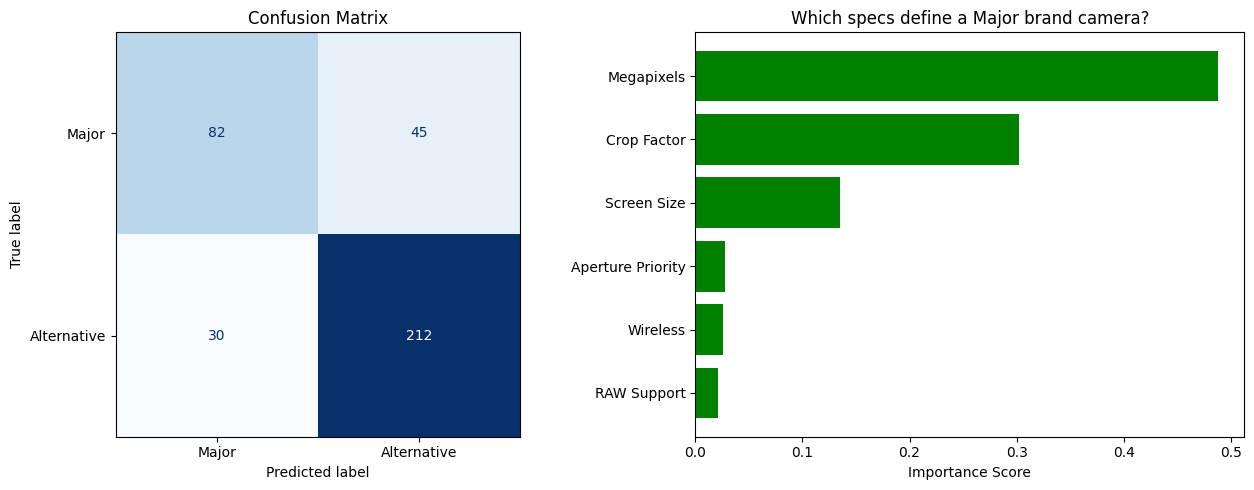


Accuracy: 79.7%
Top specs: Megapixels (48.8%) and Crop Factor (30.2%)
Combined they drive 79.0% of model decisions.


In [57]:
# Confusion matrix + feature importance side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred, labels=['Major', 'Alternative'])
ConfusionMatrixDisplay(cm, display_labels=['Major', 'Alternative']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

feature_labels = ['Megapixels', 'Crop Factor', 'Screen Size', 'RAW Support', 'Wireless', 'Aperture Priority']
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)
axes[1].barh([feature_labels[i] for i in sorted_idx], importances[sorted_idx], color='green')
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Which specs define a Major brand camera?')

plt.tight_layout()
plt.show()

top_two = np.argsort(importances)[::-1][:2]
print(f"\nAccuracy: {(y_pred == y_test).mean():.1%}")
print(f"Top specs: {feature_labels[top_two[0]]} ({importances[top_two[0]]:.1%}) and {feature_labels[top_two[1]]} ({importances[top_two[1]]:.1%})")
print(f"Combined they drive {importances[top_two].sum():.1%} of model decisions.")

In [56]:
feature_labels = ['Megapixels', 'Crop Factor', 'Screen Size', 'RAW Support', 'Wireless', 'Aperture Priority']
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

for i in sorted_idx:
    print(f"{feature_labels[i]}: {importances[i]:.1%}")


Megapixels: 48.8%
Crop Factor: 30.2%
Screen Size: 13.5%
Aperture Priority: 2.8%
Wireless: 2.6%
RAW Support: 2.1%
